In [17]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten

from tensorflow.keras.utils import to_categorical

In [18]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [19]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df.shape

(60000, 785)

In [21]:
#preprocess

X_train = df.drop('label', axis=1).values
y_train = df['label'].values 
X_test = df_test.drop('label', axis=1).values 
y_test = df_test['label'].values 

In [22]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [23]:
X_train_img = X_train.reshape(-1, 28, 28, 1)
X_test_img = X_test.reshape(-1, 28, 28)

In [24]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

**Using perceptron**

In [25]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

In [26]:
perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
history_percp = perceptron.fit(
    X_train_img, 
    y_train_cat, 
    epochs=5,
    batch_size = 32,
    validation_data = (X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8157 - loss: 0.7768 - val_accuracy: 0.8814 - val_loss: 0.4804
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8796 - loss: 0.4575 - val_accuracy: 0.8948 - val_loss: 0.4006
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8909 - loss: 0.4041 - val_accuracy: 0.9021 - val_loss: 0.3669
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8969 - loss: 0.3774 - val_accuracy: 0.9064 - val_loss: 0.3483
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9006 - loss: 0.3605 - val_accuracy: 0.9088 - val_loss: 0.3354


In [28]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [29]:
acc_percp

0.9088000059127808

**<h3>Using ANN</h3>**

In [30]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [31]:
ann.compile(optimizer='adam', loss="categorical_crossentropy", metrics=['accuracy'])

In [32]:
history_ann = ann.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9314 - loss: 0.2354 - val_accuracy: 0.9658 - val_loss: 0.1139
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9699 - loss: 0.0991 - val_accuracy: 0.9720 - val_loss: 0.0895
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9779 - loss: 0.0712 - val_accuracy: 0.9741 - val_loss: 0.0843
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9830 - loss: 0.0540 - val_accuracy: 0.9738 - val_loss: 0.0884
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9863 - loss: 0.0426 - val_accuracy: 0.9726 - val_loss: 0.0914


In [33]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [34]:
acc_ann

0.972599983215332

**<h3>Using the CNN</h3>**

In [35]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape= (28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [36]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [37]:
history_cnn = cnn.fit(
    X_train_img, 
    y_train_cat, 
    epochs=5, 
    batch_size=32, 
    validation_data=(X_test_img,y_test_cat), 
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9349 - loss: 0.2160 - val_accuracy: 0.9854 - val_loss: 0.0457
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9755 - loss: 0.0803 - val_accuracy: 0.9874 - val_loss: 0.0404
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9813 - loss: 0.0619 - val_accuracy: 0.9901 - val_loss: 0.0281
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9851 - loss: 0.0495 - val_accuracy: 0.9904 - val_loss: 0.0291
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9866 - loss: 0.0424 - val_accuracy: 0.9908 - val_loss: 0.0267


In [38]:
acc_cnn = cnn.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [39]:
acc_cnn

0.9908000230789185

In [40]:

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

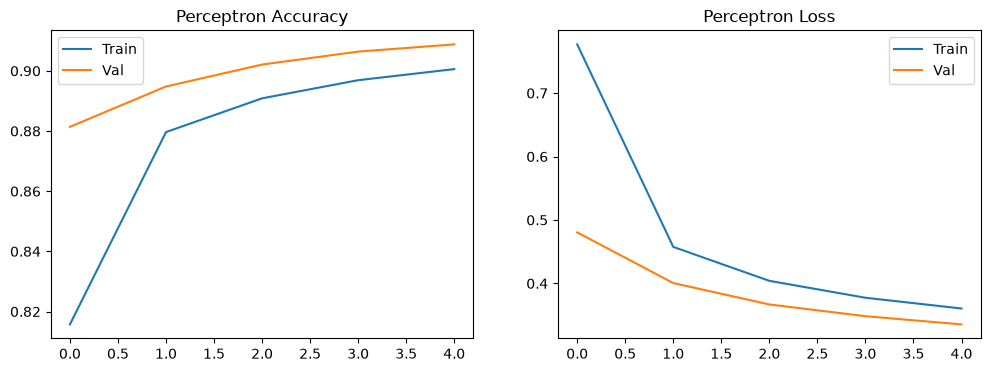

In [41]:

plot_training(history_percp, "Perceptron")

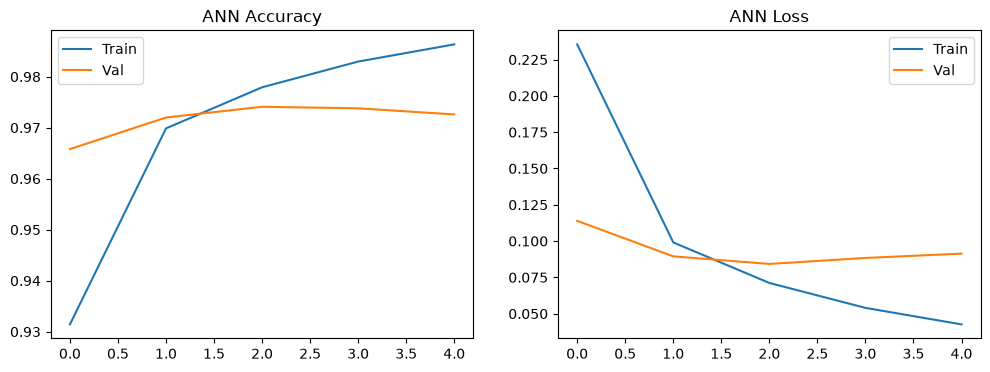

In [42]:
plot_training(history_ann, "ANN")

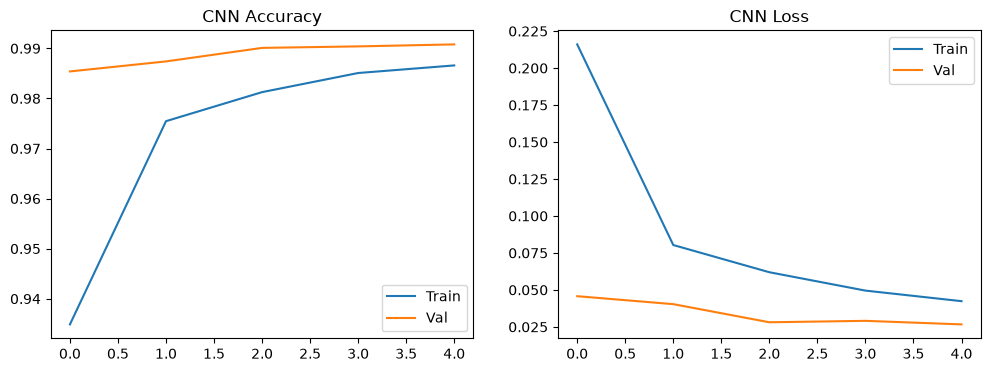

In [43]:

plot_training(history_cnn, "CNN")

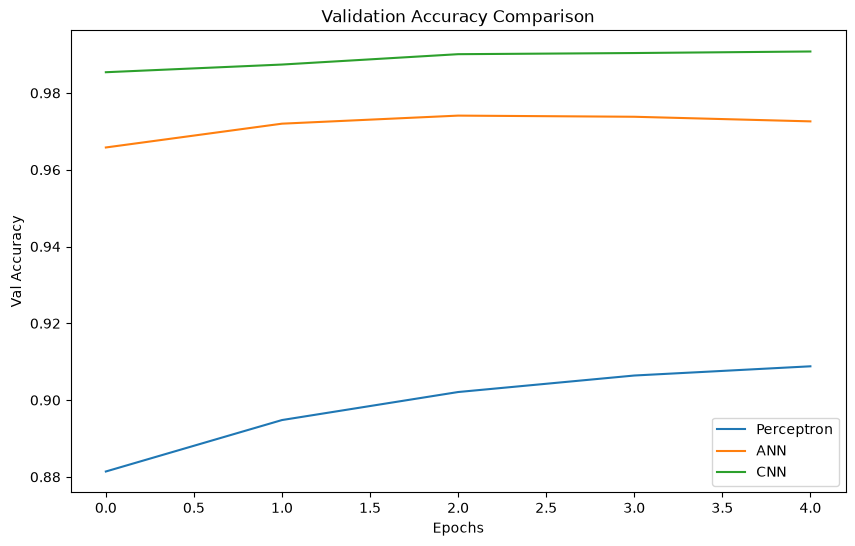

In [44]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()